# Description

## Set-Up

In [1]:
import sys
print(sys.executable)

/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/.venv/bin/python


In [2]:
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))
project_root

PosixPath('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine')

In [3]:
from src.job_intel.config import INTERIM_CLEANED_JOBS

## Import libraries

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import Counter

## Import data

In [5]:
df = pd.read_csv(INTERIM_CLEANED_JOBS)

# Titles normalisation

In [6]:
df['job_title_raw'] = df['Job Title'].astype(str).str.strip()
print("Number of rows:", len(df))
print("Unique raw titles:", df['job_title_raw'].nunique())
print("\nSample titles:")
print(df['job_title_raw'].sample(20, random_state=42).to_list())

Number of rows: 6162
Unique raw titles: 3014

Sample titles:
['Data Scientist- Machine Learning Software Engineer', 'Data Analyst', 'Data Analyst', 'Consultant, Telematics Data Engineer', 'Data & Analytics Consultant |', 'Systems/Data Analyst', 'Data Analyst', 'Data Analyst', 'Systems Analyst, Quality Data System', 'Big Data Engineer/Admin', 'Data Analyst Junior', 'Senior Data Scientist, Ad Platforms', 'Senior Marketing Data Analyst', 'Senior Data Analyst', 'Data Management Analyst (ADDM04) SEC SVCS OPS DATA GOVERNANCE - NA', 'Senior Data Scientist with Extensive Industrial Experience', 'Content Data Scientist, Apple Media Products Data Science', 'Field Applications Scientist, CA', 'Data Analyst', 'Principal Data Scientist, Machine Learning']


### Identify noise and decorators within the job titles

In [7]:
noise_terms = [

    # -------------------------------------------------
    # Contract / job-advert / recruiting meta
    # -------------------------------------------------
    "contract", "contractor", "temporary", "temp",
    "full time", "part time", "fulltime", "full",
    "freelance", "seasonal",
    "hire", "hiring",
    "opportunity", "opportunities",
    "urgent", "immediate", "immediate start", "asap",
    "apply now", "now hiring",
    "opening", "openings", "job opening",
    "position", "positions", "post", "posting",
    "reposted", "itjobs",
    "jobs", "job", "careers", "candidate",

    # -------------------------------------------------
    # Work mode / location-independent pattern
    # -------------------------------------------------
    "remote", "hybrid", "onsite", "on-site",
    "wfh", "work from home", "telecommute",

    # -------------------------------------------------
    # Time / schedule / seniority-like ordinals
    # (we handle roman numerals separately)
    # -------------------------------------------------
    "month", "months", "year", "years",
    "day", "days", "week", "weeks", "hours",
    "shift", "roster",
    "tuesday", "saturday",
    "weekend", "weekends", "weekly",
    "evenings", "evening", "nights", "night",
    "2nd", "3rd", "1st",
    "pm", "am", "00pm", "30pm",
    "yr", "yrs",
    "late",
    "stage",

    # -------------------------------------------------
    # Eligibility / HR boilerplate / generic HR meta
    # -------------------------------------------------
    "relocation", "eligibility",
    "visa", "sponsorship",
    "anywhere", "compensation",
    "resident", "candidates",
    "required", "must",
    "clearance", "secret",
    "incentives", "proficiency",
    "identity", "enrollment",
    "permanent",

    # -------------------------------------------------
    # Generic stopwords (safe to strip from titles)
    # -------------------------------------------------
    "and", "or", "with", "in", "of", "for",
    "to", "the", "at", "only", "on", "is",
    "up", "may", "as",
    "my", "re", "from",
    "into", "over", "all", "two",

    # -------------------------------------------------
    # Junk / corrupted tokens
    # -------------------------------------------------
    "s", "w", "t", "f", "bm", "ts", "â", "area4",
    "_", "_long", "d",
    "‰øùÂÆû‰π†‰øùÂ∞±‰∏ö",
    "x", "ch",
    "ihha", "ctj", "hsv",
    "mbse", "dw", "edw",
    "lrec", "idq",
    "c3", "e3", "1q",

    # -------------------------------------------------
    # Pure location tokens (we have a location column)
    # -------------------------------------------------
    # US states
    "ny", "nj", "ct", "fl", "oh", "pa", "tx", "mn", "wi",
    "nc", "sc", "al", "tn", "ky", "va", "wv", "md", "de",
    # Cities, regions, countries, generic geo
    "dallas", "chicago", "austin", "atlanta",
    "toronto", "washington", "antonio",
    "moines", "louis", "columbus", "nationwide",
    "ca", "san", "us", "la", "phoenix",
    "diego", "houston", "irving", "philadelphia",
    "francisco", "jolla", "south",
    "jacksonville", "atx", "local",
    "jersey", "jose", "ga", "california", "los",
    "angeles", "usa", "square", "sfo",
    "oklahoma", "bay", "nyc", "sf", "charlotte",
    "america", "york", "dc", "chandler",
    "canada", "tempe", "fargo", "wells",
    "east", "lake", "sinai", "harborside",
    "international", "mount", "missouri",
    "stafford", "sugar", "land", "arizona",
    "americas", "glendale", "scottsdale",
    "mesa", "gilbert", "burbank", "culver",
    "europe", "aurora", "arlington", "plano",
    "grand", "prairie", "wilmington", "lawson",
    "uk", "greenwood", "ohio",
    "india", "texas",
    # Extra locations / geo-ish
    "seattle", "denver", "norfolk", "whittier",
    "woodridge", "cerritos", "glenview",
    "bellaire", "hills", "hickory",
    "beach", "village", "acorn", "centennial",
    "midwest", "west", "ocean",

    # -------------------------------------------------
    # Languages / language requirements (not role type)
    # -------------------------------------------------
    "english", "korean", "german",
    "chinese", "spanish", "bilingual",
    "japanese", "indonesian",
    "fluent", "speaking",
    "language",

    # -------------------------------------------------
    # Companies / organisations / brand names
    # (not role semantics)
    # -------------------------------------------------
    "disney", "hbo", "star", "max",
    "apple", "ibm", "salesforce", "oracle",
    "fleishmanhillard", "veritystream",
    "epic", "tibco", "abbott", "dell",
    "gao", "cowen", "pfk", "usdc",
    "provost", "quantumblack", "fbi",
    "google", "outsights", "lacera",
    "kaiser", "tyson", "bernard",
    "ais", "avmed", "hutchinson",
    "teleflora", "facilitysource",
    "publicis", "wirecutter",
    "peacock", "anderson", "kapil",
    "bhalla", "cedars", "svendsen",
    "novi", "gtech", "point72",
    "acurian", "ppd", "horsham",
    "schaeffer", "atlantic", "microsoft",
    "hctra", "gnhcc", "qsight", "sdsa", "sdma",
    "docutech", "qliksense",
    "woocommerce", "applecare",
    "amazon", "trello",
    "upstart", "tealium",
    "cognizant", "jll", "deloitte", "lilly",
    "cooper", "spotify", "mongo", 

    # -------------------------------------------------
    # SKILLS / STACK TERMS REMOVED FROM TITLE
    # (we keep this section so we can reuse the list
    #  for skill extraction later, but they are stripped
    #  from the job title text used for embeddings)
    # -------------------------------------------------
    # Cloud / data platforms
    "azure", "sap", "teradata", "workday", "salesforce",
    "splunk", "hana", "collibra", "mongodb", "oracle",
    "hive", "snowflake", "databricks", "powerbi",
    "kafka", "kubernetes", "docker", "talend",
    "geospatial", "arcgis", "erp", "lims", "cloudera",
    "greenplum", "memsql", "celonis", "websphere",
    "sharepoint", "infosphere", "hpc",

    # Programming languages / frameworks
    "python", "java", "r", "sas", "nlp",
    "plsql", "sql", "xml", "csv", "js",

    # Data / ML / devops
    "etl", "cloud", "hadoop", "spark",
    "crm", "mdm", "aws", "devops", "cloudops",
    "pyspark", "datamodeling",

    # Misc tools / tech-y but not core role type
    "guidewire", "hub", "ecommerce", "datastage", "stack",
    "informatica", "pcr", "hplc",
    "gpu", "polygraph",
    "nifi", "elasticsearch", "logstash",
    "portal", "sdk", "cli", "scala",
    "ecomm", "systemc", "oci", "ci", "cd",
    "datalakes", "kibana", "tableau", "toad",
    "qliksense", "spotfire", "jupyter", "notebook",
    "server", "app", "apps", "node", "cpu", "graphics",

    # -------------------------------------------------
    # Tasks / processes / generic actions
    # -------------------------------------------------
    "extract", "import", "set", "start", 

    # -------------------------------------------------
    # Generic descriptors / fluff not needed in title
    # -------------------------------------------------
    "experienced", "practice", "reference", "base",
    "background", "future", "professional",
    "summer", "work", "fall", "main",
    "acceptance", "affordable", "ignite",
    "career", "early", "cost", "assurance", "experience",
    "top", "new", "world", "multiple", "strong", "smart",
    "high", "fully", "first", "fast", "moving", "extensive",
    "automatic", "virtual", "online",

    # -------------------------------------------------
    # ID codes / acronyms / job ids
    # -------------------------------------------------
    "w2", "c2c", "c4i",
    "70445br", "66201br",
    "jr1013810", "d3529", "ek020719a",
    "addm04", "s02268p", "7199u",
    "kp4457495", "84r", "daqa07",
    "jc2001", "jc2002",
    "bhjob11946_", "txho_", "opening_type",
    "null", "1yr", "150k", "1s",
    "pk", "ht", "mt", "sd", "mm", "pp",
    "qm", "rq", "dq", "mg",
    "cbch", "fhc", "cij",
    "x12", "euv", "ec",
    "usmtf", "niwc", "sisw",

    # -------------------------------------------------
    # Admin / business / finance meta (not role type)
    # -------------------------------------------------
    "claims", "enrollment", "loan", "capital", "firm", 
    "corporate", "hq", "accounts", "receivable", "priceguide",

    # -------------------------------------------------
    # Misc advert / presentation / filler words
    # -------------------------------------------------
    "now", "exciting", "needed", "please",
    "home", "campus", "things", "cities", "begin",
    "also", "works", "bus", "ab", "go", "etc",
    "resource", "items", "item", "amazing", "superstar",
    "description", "summary", "report", "reports",
    "review", "reviewer", "record", "records",
    "sample", "samples", "options", "programs", "bootcamp", "seminar",

    # -------------------------------------------------
    # Org / corporate / institutional meta
    # -------------------------------------------------
    "corporation", "foundation", "college",
    "member", "institutional", "department",
    "division", "entity", "centers",
    "initiative", "committee", "board",

    # -------------------------------------------------
    # Misc acronyms with no title meaning
    # -------------------------------------------------
    "eib", "rm", "pbm", "ams", "edss", "mpk", "cecl", "lll",
    "gsm", "mgt", "sni", "fr", "cao", "fs", "ww",
    "bfsi", "yarn", "em", "dads06", "ipp", "ho", "dm", "ut",
    "noke", "cpt", "dss", "pci", "vbp", "dlp",
    "svcs", "usgaap", "ccpa",
    "sd", "mm", "pp", "rt", "jl", "ll",
    "cbo", "hcc", "usc", "sro", "spg", "sbg",
    "dps", "bsa", "hla", "rp", "clc", "ssa", "mtv",

    # -------------------------------------------------
    # Social / consumer platforms (not title semantics)
    # -------------------------------------------------
    "twitter", "tiktok", "whatsapp", "instagram",

    # -------------------------------------------------
    # Education / training fluff (not academic roles)
    # -------------------------------------------------
    "thesis", "educational", "training",

    # -------------------------------------------------
    # Misc extremely generic / filler / junk
    # -------------------------------------------------
    "return", "e", "adjustment", "across",
    "models", "driven", "term", "value",
    "course", "release", "build", "sm",
    "school", "online", "site", "space",
    "stage", "point", "line", "place",
    "area", "inside", "next", "end",
    "back", "round", "side", "look",
    "get", "consider", "plenty", "eventually",
    "over", "specifically",

    # -------------------------------------------------
    # Extra generic job-board / advert noise
    # -------------------------------------------------
    "apply", "seller", "buyer", "store",
]


### Identify main seniority levels

In [8]:
principal = ["principal"]
executive = ["chief"]
staff = [ "staff"]
assistant = ["assistant"]
supervisor = [ "supervisor", "supervisory"]
lead = ["lead", "team lead", "tech lead", "coordinator"]
senior = [ "senior", "sr", "sr."]
manager = ["manager", "director", "head of", "head,",
           "head -", "vp", "vice president", "head",
           "vice", "officer", "avp"]
mid = ["mid","mid level","associate","midlevel","intermediate"]
junior = ["junior","jr", "jr.", "entry level", "graduate", "grad",
          "entry", "undergraduate", "internship", "intern", "trainee","unpaid"]


### Seniority tokens to be removed

In [9]:
# Seniority tokens (conservative, lowercase)
seniority_tokens = [
    # principal / lead tiers
    "principal", "lead",
    "team lead", "tech lead",
    # senior
    "senior", "sr", "sr.",
    # manager / director / vp
    "manager", "director", "head of",
    "head,", "head -", "vp",
    "vice president", "head", "vice",
    "officer", "avp",
    # mid
    "mid", "mid level", "associate",
    "midlevel", "intermediate",
    # junior
    "junior", "jr", "jr.",
    "entry", "entry level", "graduate",
    "grad", "undergraduate", "trainee",
    "unpaid",
    #executive
    "chief", "staff", "supervisor", "supervisory", 
    "assistant", "coordinator", "internship", "intern", 
    " i ", "ii", "iii", "iv"
]



### Dictionary of typos found

In [10]:
typo_map = {
    "sceintist": "scientist",
    "scientist_": "scientist",
    "ebgineer": "engineer",
    "behavorial": "behavioral",
    "cinical": "clinical",
    "speciliest": "specialist",
    "reseach": "research",
    "automaion": "automation",
    "industial": "industrial",
    "billingual": "bilingual",
    "pharmacovgilance": "pharmacovigilance",
    "leadeship": "leadership",
}


### Function to translate the seniority classes into a column

In [11]:
def detect_seniority(text):
    x = text.lower()

    if any(k in x for k in principal):
        return "principal"
    if any(k in x for k in lead):
        return "lead"
    if any(k in x for k in senior):
        return "senior"
    if any(k in x for k in manager):
        return "manager"
    if any(k in x for k in mid):
        return "mid"
    if any(k in x for k in junior):
        return "junior"
    if any(k in x for k in executive):
        return "executive"
    if any(k in x for k in assistant):
        return "assistant"
    if any(k in x for k in staff):
        return "staff"
    if any(k in x for k in supervisor):
        return "supervisor"

    return "unknown"

In [12]:
# Build regex patterns from your existing lists/dicts
noise_pattern = r"\b(" + "|".join(re.escape(t) for t in noise_terms) + r")\b"
seniority_pattern = r"\b(" + "|".join(re.escape(t) for t in seniority_tokens) + r")\b"

### Unified minor edits function

In [13]:
def clean_job_title(text):
    """
    Return:
        (clean_title, seniority_roman)
    clean_title: lowercase, no noise, no seniority, no junk
    seniority_roman: 'junior' / 'mid' / 'senior' / 'lead' or None
    """
    if pd.isna(text):
        return text, None

    # 0) normalise case + pad with spaces
    text = f" {str(text).lower().strip()} "

    # 1) normalise common separators early so 'i/ii' becomes 'i ii'
    text = re.sub(r"[-/|\\,]", " ", text)

    # 2) detect Roman numeral seniority (longest to shortest)
    seniority = None
    if re.search(r"\biv\b", text):
        seniority = "lead"
    elif re.search(r"\biii\b", text):
        seniority = "senior"
    elif re.search(r"\bii\b", text):
        seniority = "mid"
    elif re.search(r"\bi\b", text):
        seniority = "junior"

    # 3) remove Roman numeral tokens from the text regardless
    text = re.sub(r"\b(iv|iii|ii|i)\b", " ", text)

    # 4) remove noise words/phrases
    text = re.sub(noise_pattern, " ", text)

    # 5) separators, brackets (run again is harmless)
    text = re.sub(r"[-/|\\,]", " ", text)
    text = re.sub(r"[()\[\]{}]", " ", text)

    # 6) remove seniority words/phrases (non-Roman, e.g. 'senior', 'lead')
    text = re.sub(seniority_pattern, " ", text)

    # 7) punctuation → space
    text = re.sub(r"[^\w\s]", " ", text)

    # 8) isolated numbers
    text = re.sub(r"\b\d+\b", " ", text)

    # 9) remove specific junk phrase
    text = re.sub(r"\bover experience\b", " ", text)

    # 10) typo corrections
    for wrong, correct in typo_map.items():
        text = re.sub(rf"\b{re.escape(wrong)}\b", correct, text)

    # 11) collapse whitespace and strip padding
    text = " ".join(text.split())

    return text, seniority


In [14]:
df["clean_title_and_roman"] = df["job_title_raw"].apply(clean_job_title)
df["job_title_base"] = df["clean_title_and_roman"].apply(lambda x: x[0])
df["seniority_roman"] = df["clean_title_and_roman"].apply(lambda x: x[1])

# combine roman seniority with keyword-based seniority
df["seniority"] = df.apply(
    lambda row: row["seniority_roman"] if row["seniority_roman"] is not None
    else detect_seniority(row["job_title_raw"]),
    axis=1
)
print("Unique base titles:", df['job_title_base'].nunique())

Unique base titles: 2035


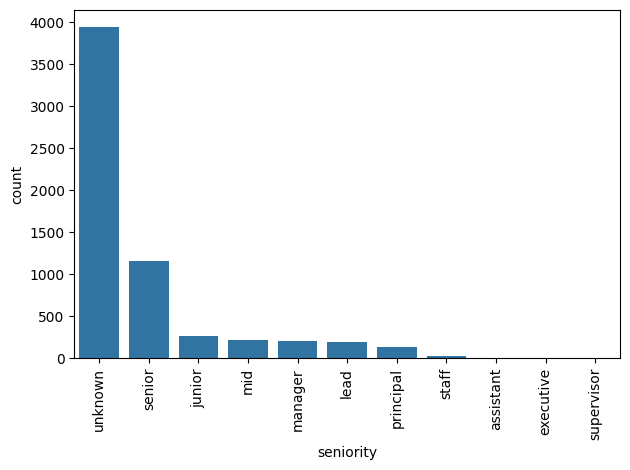

In [15]:
order = df['seniority'].value_counts().index

sns.countplot(
    data = df,
    x = 'seniority',
    order = order
)
plt.xticks(rotation = 90)
plt.tight_layout()

In [16]:
df['job_title_base'].value_counts()

job_title_base
data analyst                            1212
data scientist                           533
data engineer                            467
big data engineer                         85
business data analyst                     69
                                        ... 
quantitative researcher sales              1
scientist wind vulnerability               1
data engineer dive big data pto            1
supply chain analytics consultant ft       1
data analyst audit                         1
Name: count, Length: 2035, dtype: int64

Save current BOW for iterations

In [17]:
# Combine all titles into one long list of words
all_words = " ".join(df['job_title_base']).split()

# Count frequencies
word_counts = Counter(all_words)

# Convert to a DataFrame for easy viewing
bow = pd.DataFrame(word_counts.items(), columns=['word', 'count']).sort_values('count', ascending=False)

from src.job_intel.config import INTERIM_DATA_DIR
#bow.to_csv(INTERIM_DATA_DIR / "bow_v3.csv", index=False)

len(bow)


1136

In [18]:
df.to_csv(INTERIM_DATA_DIR / 'job_titles_cleaned.csv', index=False)